<a href="https://colab.research.google.com/github/Vasista-G/GoogleCollab_Python/blob/main/SalesDataAnalysis/SalesDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from pathlib import Path

#Read all months sales.csv and combine it into a single consolidated CSV
folder = Path("/content")

files = folder.glob("*.csv")

combined_df = pd.DataFrame()

for file in files:
    df = pd.read_csv(file)
    combined_df = pd.concat([combined_df, df])

combined_df.to_csv("combined.csv", index=False)

In [77]:
all_month = pd.read_csv("combined.csv")
all_month.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,222910,Apple Airpods Headphones,1,150,07/26/19 16:51,"389 South St, Atlanta, GA 30301"
1,222911,Flatscreen TV,1,300,07/05/19 08:55,"590 4th St, Seattle, WA 98101"
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301"
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301"
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101"


In [83]:
#Drop Nan values
all_month.dropna(inplace=True)

#Convert Order Date to Pands Date
#errors="coerce" is particularly useful here: values that cannot be parsed will become NaT.

all_month["Order Date"] = pd.to_datetime(all_month["Order Date"], format = "%m/%d/%y %H:%M", errors = "coerce")

#Drop all NaT Dates
all_month["Order Date"].isna().sum()


np.int64(0)

In [88]:
#Adding Month Column - Extract from Order Date

all_month["Month"] = all_month["Order Date"].dt.month
all_month.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,222910,Apple Airpods Headphones,1,150,2019-07-26 16:51:00,"389 South St, Atlanta, GA 30301",7
1,222911,Flatscreen TV,1,300,2019-07-05 08:55:00,"590 4th St, Seattle, WA 98101",7
2,222912,AA Batteries (4-pack),1,3.84,2019-07-29 12:41:00,"861 Hill St, Atlanta, GA 30301",7
3,222913,AA Batteries (4-pack),1,3.84,2019-07-28 10:15:00,"190 Ridge St, Atlanta, GA 30301",7
4,222914,AAA Batteries (4-pack),5,2.99,2019-07-31 02:13:00,"824 Forest St, Seattle, WA 98101",7


In [90]:
# Adding Sales Total amount column

#The Price Each has a str DataType - Converting it into Numeric
all_month["Price Each"] = pd.to_numeric(all_month["Price Each"])
all_month["Quantity Ordered"] = pd.to_numeric(all_month["Quantity Ordered"])

#Add Column by Vectorization
all_month["Sales_total"] = all_month["Quantity Ordered"] * all_month["Price Each"]
all_month.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales_total
0,222910,Apple Airpods Headphones,1,150.00,2019-07-26 16:51:00,"389 South St, Atlanta, GA 30301",7,150.00
1,222911,Flatscreen TV,1,300.00,2019-07-05 08:55:00,"590 4th St, Seattle, WA 98101",7,300.00
2,222912,AA Batteries (4-pack),1,3.84,2019-07-29 12:41:00,"861 Hill St, Atlanta, GA 30301",7,3.84
3,222913,AA Batteries (4-pack),1,3.84,2019-07-28 10:15:00,"190 Ridge St, Atlanta, GA 30301",7,3.84
4,222914,AAA Batteries (4-pack),5,2.99,2019-07-31 02:13:00,"824 Forest St, Seattle, WA 98101",7,14.95


In [98]:
#1. What is the best month for sales? How much was earned that month

all_month.groupby("Month")["Sales_total"].sum()

,Sales_total
Month,
1,1822256.73
2,2202022.42
3,2807100.38
4,3390670.24
5,3152606.75
6,2577802.26
7,2647775.76
8,2244467.88
9,2097560.13


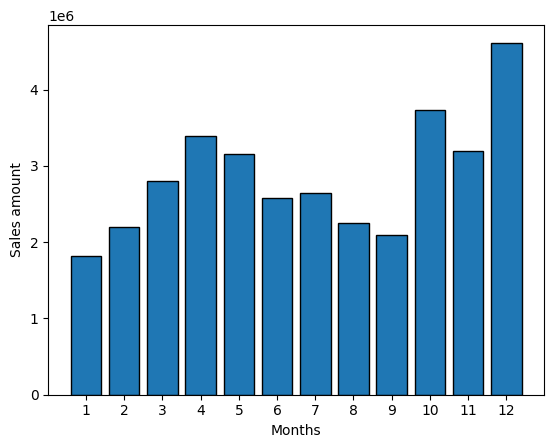

In [108]:
import matplotlib.pyplot as plt

months = range(1,13)

plt.bar(months,all_month.groupby("Month")["Sales_total"].sum(), ec = "black")
plt.xticks(months)
plt.ylabel("Sales amount")
plt.xlabel("Months")
plt.show()
